# This uplift model tells us:
# - Which customers are "Persuadable" (respond only if targeted).
# - Which clusters have highest incremental impact.
# - How much budget we can save by targeting smarter.

In [1]:
# -----------------------------------------------------------------------------
# Uplift Modeling: Predicting Incremental Campaign Impact
# -----------------------------------------------------------------------------
# Business Question: 
# Which customers should we target to maximize campaign ROI?
#
# Instead of predicting who will respond (Propensity Model), 
# Uplift Modeling predicts who will respond BECAUSE of the campaign.
#
# This helps us avoid wasting money on:
# - Customers who would buy anyway (Sure Things)
# - Customers who won't buy regardless (Lost Causes)
# - Customers who are annoyed by campaigns (Sleeping Dogs)
#
# We want to find the "Persuadables" – those who only buy if targeted.
#
# Dataset: Our preprocessed data with cluster assignments
# Treatment: Customers who received past campaigns (using AcceptedCmp flags)
# Control: Customers who never received campaigns (inferred from data)
# Target: Response (accepted last campaign or not)
# -----------------------------------------------------------------------------


# 1. Import Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve

# For uplift modeling
from sklift.models import ClassTransformation
from sklift.metrics import uplift_at_k, qini_auc_score
from sklift.viz import plot_uplift_curve, plot_qini_curve

import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

In [2]:

# 2. Load Data with Cluster Assignments


# Load clustered data (contains ID, features, and Cluster labels)
df = pd.read_csv('../../data/preprocessed/customers_with_clusters.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

Dataset shape: (2229, 29)
Columns: ['Education', 'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending', 'Total_Purchases', 'Children_at_home', 'Living_With', 'Family_Size', 'Cluster']

Cluster distribution:
Cluster
0    642
1    614
2    562
3    411
Name: count, dtype: int64


In [4]:

# 3. Create Treatment and Target Variables
#
# In uplift modeling, we need:
# - **treatment**: Whether customer was exposed to campaign (1) or not (0)
# - **target**: Whether customer converted (1) or not (0)
#
# Since we don't have explicit control groups in this dataset,
# we'll create a proxy using campaign history.

# List of campaign columns
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 
                 'AcceptedCmp4', 'AcceptedCmp5']

# Treatment: Customer received at least one campaign
# (If they accepted any campaign, they definitely received it.
#  For those who never accepted, we assume they received some campaigns
#  but didn't respond – this is a limitation but workable)
df['treatment'] = (df[campaign_cols].sum(axis=1) > 0).astype(int)

# Target: Accepted the last campaign (Response)
# This is our conversion indicator
df['target'] = df['Response']

print(f"Treatment group size (received campaigns): {df['treatment'].sum()}")
print(f"Control group size (no campaigns): {(1-df['treatment']).sum()}")
print(f"\nTarget acceptance rate: {df['target'].mean():.2%}")


# Check treatment vs control conversion rates
treatment_rate = df[df['treatment']==1]['target'].mean()
control_rate = df[df['treatment']==0]['target'].mean()

print(f"Conversion rate - Treatment group: {treatment_rate:.2%}")
print(f"Conversion rate - Control group: {control_rate:.2%}")
print(f"Lift: {(treatment_rate - control_rate):.2%}")

Treatment group size (received campaigns): 462
Control group size (no campaigns): 1767

Target acceptance rate: 14.98%
Conversion rate - Treatment group: 40.69%
Conversion rate - Control group: 8.26%
Lift: 32.43%


In [5]:

#  4. Prepare Features for Modeling
#
# We'll use your existing features plus cluster labels.
# Exclude campaign columns and target-related fields.


# Define features (exclude target, treatment, and campaign columns)
exclude_cols = ['ID', 'target', 'treatment', 'Response'] + campaign_cols
if 'Total_Accepted_Campaigns' in df.columns:
    exclude_cols.append('Total_Accepted_Campaigns')

# Get all numeric columns
feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns 
                if col not in exclude_cols]

# Add cluster as a feature (already numeric)
# feature_cols already includes 'Cluster' since it's numeric

print(f"Using {len(feature_cols)} features:")
print(feature_cols)

# Prepare feature matrix
X = df[feature_cols].copy()
treatment = df['treatment']
target = df['target']

# Train/test split (preserve treatment/control ratios)
X_train, X_test, t_train, t_test, y_train, y_test = train_test_split(
    X, treatment, target, test_size=0.3, random_state=42, stratify=treatment
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Using 21 features:
['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'Age', 'Customer_Tenure_Days', 'Total_Spending', 'Total_Purchases', 'Children_at_home', 'Family_Size', 'Cluster']
Training set size: 1560
Test set size: 669


In [6]:

# 5. Build Uplift Model
#
# We'll use the **Class Transformation Method**:
# - Creates a new target variable Z = 1 if treated AND converted, else 0
# - Then trains a single classifier to predict P(Z=1 | X)
# - Uplift score = P(Z=1 | X) * 2 - 1 (simplified)
#
# This is simpler than two-model approaches and works well in practice.

# Initialize and fit uplift model
uplift_model = ClassTransformation(estimator=RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
))

# Fit the model
uplift_model.fit(X_train, y_train, t_train)

# Predict uplift scores on test set
uplift_scores = uplift_model.predict(X_test)

print("Uplift model trained successfully")


Uplift model trained successfully


Uplift at top 10%: 0.0000
Uplift at top 20%: 0.3103
Uplift at top 30%: 0.4745

Qini coefficient: -0.3603


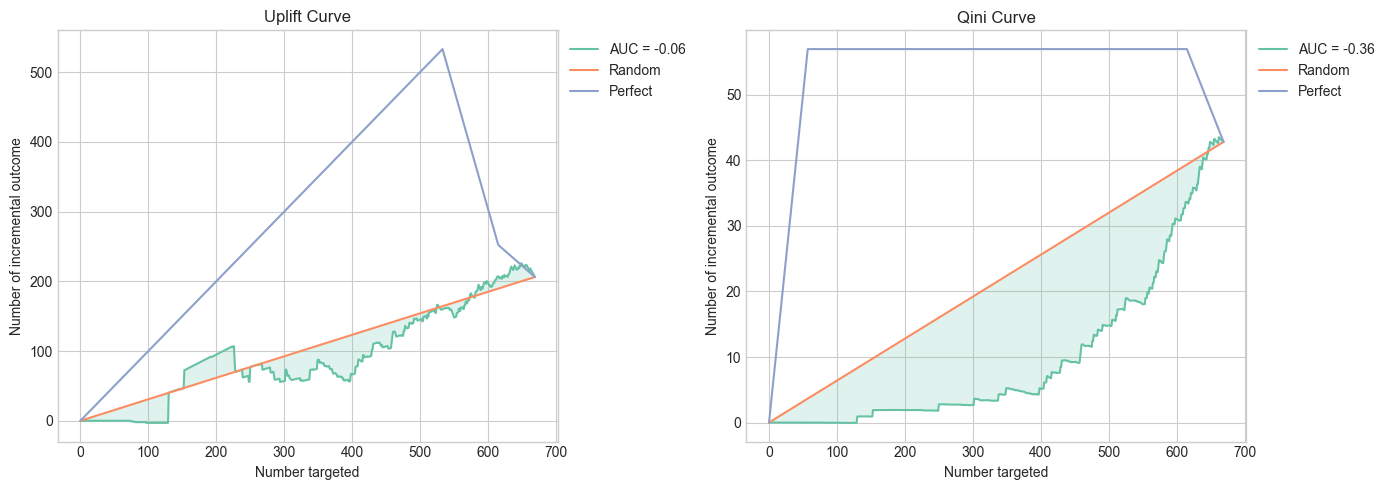

In [7]:

# 6. Evaluate Uplift Model
#
# Key metrics:
# - **Uplift at k%**: Average uplift when targeting top k% of customers
# - **Qini coefficient**: Measures how well model ranks customers by uplift

#
# Calculate uplift at different targeting depths
for k in [10, 20, 30]:
    u_at_k = uplift_at_k(y_test, uplift_scores, t_test, k=k/100, strategy='overall')
    print(f"Uplift at top {k}%: {u_at_k:.4f}")

# Qini coefficient (higher = better ranking)
qini_score = qini_auc_score(y_test, uplift_scores, t_test)
print(f"\nQini coefficient: {qini_score:.4f}")


# Plot Uplift and Qini curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_uplift_curve(y_test, uplift_scores, t_test, ax=ax1)
ax1.set_title('Uplift Curve')

plot_qini_curve(y_test, uplift_scores, t_test, ax=ax2)
ax2.set_title('Qini Curve')

plt.tight_layout()
plt.show()

Uplift (incremental conversion rate) by Cluster:
cluster
0    0.3175
1    0.2479
2    0.2034
3    0.4102
dtype: float64


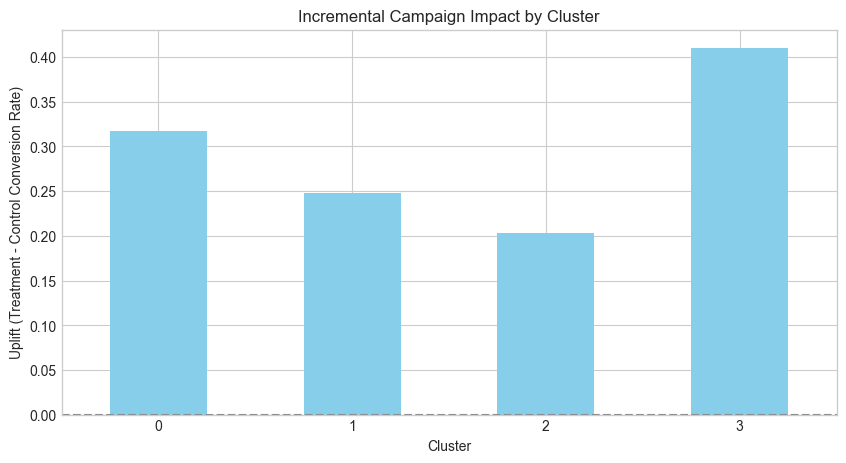

In [8]:

# 7. Segment-Level Uplift Analysis
#
# See how uplift varies across our existing clusters

# Add predictions to test set
test_df = X_test.copy()
test_df['true_target'] = y_test
test_df['treatment'] = t_test
test_df['uplift_score'] = uplift_scores
test_df['cluster'] = df.loc[X_test.index, 'Cluster']

# Calculate uplift by cluster
cluster_uplift = test_df.groupby('cluster').apply(
    lambda g: (
        g[g['treatment']==1]['true_target'].mean() - 
        g[g['treatment']==0]['true_target'].mean()
    )
).round(4)

print("Uplift (incremental conversion rate) by Cluster:")
print(cluster_uplift)

# Visualize
plt.figure(figsize=(10, 5))
cluster_uplift.plot(kind='bar', color='skyblue')
plt.axhline(y=0, color='gray', linestyle='--')
plt.title('Incremental Campaign Impact by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Uplift (Treatment - Control Conversion Rate)')
plt.xticks(rotation=0)
plt.show()

In [9]:

# 8. Who Should We Target?
#
# Combine uplift scores with business constraints

# Add scores to full dataset
df['uplift_score'] = uplift_model.predict(df[feature_cols])

# Define targeting strategy
df['target_priority'] = pd.qcut(df['uplift_score'], q=5, 
                                 labels=['Lowest', 'Low', 'Medium', 'High', 'Highest'])

# Show profile of highest uplift segment
print("Profile of Highest Uplift Customers:")
print(df[df['target_priority'] == 'Highest'][feature_cols].mean().round(2))


# Business impact simulation
total_customers = len(df)
campaign_cost_per_customer = 10  # Assume $10 per customer
conversion_value = 100  # Assume $100 per conversion

# Strategy 1: Target everyone
cost_all = total_customers * campaign_cost_per_customer
conversions_all = df['target'].sum()  # Historical baseline
revenue_all = conversions_all * conversion_value
roi_all = (revenue_all - cost_all) / cost_all

# Strategy 2: Target only top 30% by uplift
target_30pct = df.nlargest(int(0.3 * total_customers), 'uplift_score')
cost_30pct = len(target_30pct) * campaign_cost_per_customer
conversions_30pct = target_30pct['target'].sum()  # Expected if treatment effect holds
revenue_30pct = conversions_30pct * conversion_value
roi_30pct = (revenue_30pct - cost_30pct) / cost_30pct

print("\n" + "="*60)
print("BUSINESS IMPACT SIMULATION")
print("="*60)
print(f"Target Everyone:")
print(f"  Cost: ${cost_all:,.0f}")
print(f"  Expected Conversions: {conversions_all}")
print(f"  Revenue: ${revenue_all:,.0f}")
print(f"  ROI: {roi_all:.1%}")
print()
print(f"Target Top 30% by Uplift:")
print(f"  Cost: ${cost_30pct:,.0f}")
print(f"  Expected Conversions: {conversions_30pct}")
print(f"  Revenue: ${revenue_30pct:,.0f}")
print(f"  ROI: {roi_30pct:.1%}")
print(f"  Cost Savings: ${cost_all - cost_30pct:,.0f}")

Profile of Highest Uplift Customers:
Income                  34438.70
Recency                    54.02
MntWines                    2.68
MntFruits                   1.05
MntMeatProducts             2.44
MntFishProducts             1.33
MntSweetProducts            1.04
MntGoldProds                1.72
NumDealsPurchases           1.55
NumWebPurchases             1.55
NumCatalogPurchases         0.13
NumStorePurchases           3.17
NumWebVisitsMonth           6.05
Complain                    0.02
Age                        53.39
Customer_Tenure_Days     4532.00
Total_Spending             10.25
Total_Purchases             6.41
Children_at_home            1.27
Family_Size                 2.91
Cluster                     1.71
dtype: float64

BUSINESS IMPACT SIMULATION
Target Everyone:
  Cost: $22,290
  Expected Conversions: 334
  Revenue: $33,400
  ROI: 49.8%

Target Top 30% by Uplift:
  Cost: $6,680
  Expected Conversions: 10
  Revenue: $1,000
  ROI: -85.0%
  Cost Savings: $15,610


In [12]:

# 9. Actionable Recommendations


# Final targeting list by cluster
target_list = df[df['target_priority'].isin(['High', 'Highest'])][['Cluster', 'uplift_score']].copy()
target_list['cluster'] = target_list['Cluster']

print("\n" + "="*60)
print("TARGETING RECOMMENDATIONS")
print("="*60)
print(f"Total customers to target: {len(target_list)}")
print(f"\nBy Cluster:")
print(target_list['cluster'].value_counts().sort_index())

# Save targeting list
target_list.to_csv('../../data/preprocessed/target_customers_demographic_uplift.csv', index=False)
print("\nSaved targeting list to: ../../data/preprocessed/target_customers_demographic_uplift.csv")



TARGETING RECOMMENDATIONS
Total customers to target: 892

By Cluster:
cluster
0     52
1    464
2    110
3    266
Name: count, dtype: int64

Saved targeting list to: ../../data/preprocessed/target_customers_demographic_uplift.csv
